# 03 — Optuna: búsqueda bayesiana de hiperparámetros

**Entrada** : `{BUCKET}/datasets_fe/<dataset_fe>.parquet` (salida de `02_FE`)
**Salida**  : `{BUCKET}/exp/<EXPERIMENTO>/` — hiperparámetros, trials, importancia de variables, gráficos
**Leaderboard**: `{BUCKET}/exp/leaderboard.csv` — una fila por experimento, para comparar entre sí

Cómo funciona:

1. **El nombre del experimento sale del nombre del dataset + la variable respuesta elegida.**
   Todas las palancas de `01` y `02` viven en el nombre del parquet; este notebook lo parsea
   y le suma la palanca propia (qué columna `clase_*` se predice). Así cada combinación
   tiene su carpeta, su study de Optuna y su fila en el leaderboard, sin pisarse.
2. **Los meses de train / validation / test se declaran a mano** en `PARAM`. Optuna optimiza
   contra `val`; `test` es holdout y se mide una sola vez al final. Cambiar la partición
   genera otro experimento (los meses entran en el nombre), así que no se pisan entre sí.
3. **Control de data leakage** antes de entrenar (celda 4). Si algo falla, el notebook corta.
4. **WAPE siempre en toneladas**, reconstruyendo el nivel si la respuesta es `_norm` o `_delta`,
   y agregando por producto (que es como se evalúa la competencia).
5. **Las predicciones salen con `product_id` / `customer_id` / `Agrupacion_ID`** y el mes
   objetivo, para poder armar la entrega.

> **Corriendo en una máquina spot**: el study se respalda al bucket cada
> `backup_cada_n_trials` trials, y también si la celda se interrumpe. Si Google mata
> la VM en el medio, creás una nueva desde el template, corrés esta misma celda y
> Optuna **retoma desde el último respaldo** en vez de empezar de cero. Los trials se
> acumulan en el mismo `study_name`, que sale del nombre del experimento.


## 0 — Ambiente

In [6]:
!pip install -q uv
!uv pip install -q pyarrow polars lightgbm optuna sqlalchemy plotly matplotlib

In [7]:
import json, os, re, shutil, sys
import os
from pathlib import Path

import numpy as np
import polars as pl


# ── RUTAS DEL BUCKET ──────────────────────────────────────────────────────
# VM de la catedra -> ~/buckets/b1   |   Colab -> /content/buckets/b1
def resolver_bucket() -> Path:
    # 1) LABO3_BUCKET: para correr fuera de la nube (server propio, notebook local).
    #    export LABO3_BUCKET=/ruta/a/mi/bucket   (o os.environ[...] antes de esta celda)
    env = os.environ.get("LABO3_BUCKET")
    if env:
        p = Path(env).expanduser().resolve()
        p.mkdir(parents=True, exist_ok=True)
        return p
    # 2) rutas conocidas: Colab y la VM de GCP
    # ~/buckets/b1 primero: es donde lo monta la instalacion de la catedra,
    # y sirve para cualquier usuario de la VM.
    for cand in (Path.home() / "buckets" / "b1",
                 "/content/buckets/b1",
                 "/home/ds/buckets/b1"):
        if Path(cand).is_dir():
            return Path(cand)
    raise RuntimeError(
        "No encontre el bucket. Opciones: "
        "(a) Colab / VM de GCP -> corre la celda de init del ambiente; "
        "(b) server propio o local -> defini LABO3_BUCKET antes de esta celda, ej. "
        "os.environ['LABO3_BUCKET'] = '/home/usuario/labo3-bucket'"
    )


BUCKET  = resolver_bucket()
RUTA_FE = BUCKET / "datasets_fe"          # entrada: lo que dejo 02_FE
RUTA_EXP = BUCKET / "exp"                 # salida: una carpeta por experimento
RUTA_EXP.mkdir(parents=True, exist_ok=True)

print(f"BUCKET : {BUCKET}")
print(f"\nDatasets FE disponibles en {RUTA_FE}:")
for p in sorted(RUTA_FE.glob("*.parquet")):
    print(f"  - {p.name}")

BUCKET : /home/ds/buckets/b1

Datasets FE disponibles en /home/ds/buckets/b1/datasets_fe:
  - preprocesado_grpClienteProducto_fill0_denseLife_24lags_recta_2deltas.parquet


## 1 — Palancas

Lo único que se toca a mano: **qué dataset FE** y **qué variable respuesta**. El resto del
nombre del experimento se deduce solo.

Las tres respuestas posibles que deja `02_FE` (elegir UNA, las otras se excluyen de las features):

| `TARGET` | qué es | reconstrucción a toneladas |
|---|---|---|
| `clase_tn`       | toneladas a `t+2`, escala original | ninguna |
| `clase_tn_norm`  | la misma, normalizada con `B0`/`B1` de la ventana de lags | desnormalizar (`lag=-2`) |
| `clase_tn_delta` | `clase_tn_norm - tn0_norm` (cambio a 2 períodos) | sumar `tn0_norm` y desnormalizar |

El WAPE se mide **siempre en toneladas**, así los tres son comparables en el leaderboard.

In [ ]:
def rango_meses(desde: int, hasta: int) -> list:
    """Lista de periodos AAAAMM consecutivos, inclusive: rango_meses(201701, 201703)
    -> [201701, 201702, 201703]. Solo para no escribir 36 numeros a mano."""
    a, b = (desde // 100) * 12 + desde % 100, (hasta // 100) * 12 + hasta % 100
    return [((m - 1) // 12) * 100 + ((m - 1) % 12) + 1 for m in range(a, b + 1)]


PARAM = {
    # ── MODO ─────────────────────────────────────────────────────────────
    # 'cluster'  -> un study de Optuna POR CLUSTER (seccion 6.bis). Requiere un
    #               dataset con cluster_dtw (sufijo _dtwN, lo genera 02_FE_dtw).
    # 'global'   -> un unico study sobre todos los productos (secciones 6 y 7).
    # Las celdas del modo que no corresponda se saltean SOLAS: podes usar
    # Restart Kernel and Run All Cells sin tener que saltear nada a mano.
    'modo': 'cluster',

    # ── PALANCA 0: dataset de entrada (nombre exacto, de la lista de arriba) ──
    'dataset_fe': 'preprocesado_grpClienteProducto_fill0_denseLife_24lags_recta_2deltas_dtw2.parquet',

    # ── PALANCA 1: VARIABLE RESPUESTA ────────────────────────────────────
    # 'clase_tn' | 'clase_tn_norm' | 'clase_tn_delta'
    'target': 'clase_tn_delta',

    # ── PALANCA 2: horizonte de prediccion (DEBE coincidir con 02_FE) ────
    # Define el GAP obligatorio entre train y validacion (control de leakage).
    'horizonte': 2,

    # ── PALANCA 3: MESES DE TRAIN / VALIDATION / TEST (hardcodeados) ─────
    #   train : lo que ve el modelo en cada trial de Optuna.
    #   val   : lo que Optuna MINIMIZA. Es la unica senial que guia la busqueda.
    #   test  : holdout. NO participa de Optuna; se mide UNA vez al final.
    #
    # REGLA DE ORO (la valida la celda de leakage, no se puede saltear):
    #   max(train) + horizonte <= min(val)      y      max(val) + horizonte <= min(test)
    'meses_train': rango_meses(201701, 201905),
    'meses_val':   [201907, 201908],
    'meses_test':  [201910],

    # Reentrenar con train+val antes de medir test (mas datos, mismo hiperparametro).
    'reentrenar_con_val_para_test': True,

    # ── PALANCA 4: MUESTREO DE CLIENTES PARA TRAIN ───────────────────────
    # N = se queda con 1 de cada N clientes en los meses de TRAIN. None = todos.
    #
    # Por que existe: el dataset completo (10M filas x 616 columnas) no entra en una
    # VM de 60 GB cuando LightGBM arma su matriz interna -- muere por OOM con ~62 GB
    # de RSS -- y ademas un solo trial con todas las filas tarda ~2 h, o sea que 50
    # trials serian dias. El trabajo de Optuna es RANKEAR configuraciones, y ese
    # ranking es robusto al submuestreo.
    #
    # Se muestrea por CLIENTE, no por fila: cada cliente elegido conserva su historia
    # completa. Samplear filas al azar rompe las series y arruina los 24 lags.
    #
    # Los meses de VAL y TEST NO se muestrean nunca: la metrica se mide siempre sobre
    # los datos completos, asi los experimentos quedan comparables entre si.
    #
    # Entra en el nombre del experimento (__cli1deN): cambiarlo es otro experimento.
    'muestreo_clientes': 4,

    # ── PALANCA 4.bis: TOP N CLIENTES POR TONELADAS ──────────────────────
    # Alternativa a 'muestreo_clientes'. En vez de 1 de cada N clientes al azar,
    # se queda con los N clientes que MAS toneladas compraron.
    #
    # Si esta seteada, MANDA sobre 'muestreo_clientes' (se ignora esa otra).
    # None = desactivada, vale lo de arriba.
    #
    # OJO, no es lo mismo que muestrear. El hash toma un subconjunto representativo:
    # el modelo ve la misma distribucion que va a enfrentar, con menos filas. El top N
    # CAMBIA LA POBLACION: entrena solo con clientes grandes pero se lo evalua contra
    # todos, incluidos los chicos que nunca vio. Puede mejorar el WAPE (si Kaggle mide
    # toneladas, los grandes mueven la aguja) o empeorarlo. Hay que medirlo.
    #
    # El ranking se calcula SOLO con los meses de train: elegir los clientes mirando
    # tambien val/test seria filtrar el futuro hacia la seleccion de datos.
    #
    # Entra en el nombre del experimento como __cliTopN.
    'top_clientes': 50,

    # ── PALANCA 5: WAPE agregado por producto (como evalua la competencia) ──
    'wape_por_producto': True,

    # ── PALANCA 6: objetivo de LightGBM ──────────────────────────────────
    # 'regression' | 'regression_l1' | 'tweedie' | 'poisson'
    # OJO: tweedie/poisson exigen target >= 0 -> solo con target='clase_tn'.
    'objective_lgbm': 'regression',
    'tweedie_optimizar': True,

    # ── PALANCA 7: trials nuevos por corrida (se acumulan en el study) ───
    'n_trials': 50,

    # ── SPOT: cada cuantos trials se respalda el study al bucket ────────
    'backup_cada_n_trials': 5,

    # ── PALANCA 8: regularizacion ('normal' | 'fuerte') ─────────────────
    'regularizacion': 'normal',

    # ── PALANCA 8b: techo de arboles del espacio de busqueda ────────────
    # Optuna sortea n_estimators entre 100 y este valor. El tiempo de LightGBM crece
    # casi lineal en n_estimators, asi que bajarlo de 2000 a 500 divide por ~4 el
    # tiempo de la busqueda; con learning_rate razonable, 500 arboles ya saturan.
    # Entra en el nombre del experimento si no es 2000: cambia el espacio de busqueda
    # y no se pueden mezclar trials de espacios distintos en el mismo study.
    'techo_arboles': 500,

    # ── PALANCA 9: peso por recencia. None = todos los meses pesan igual ──
    'decay_recencia': None,

    # ── PALANCA 10: sampling extra de filas de train (None = todas) ──────
    # Se aplica ADEMAS de 'muestreo_clientes', ya sobre las filas cargadas.
    # Normalmente None: preferi 'muestreo_clientes', que no rompe las series.
    'sampling_frac': None,

    # ── PALANCA 11: features a EXCLUIR a mano (ademas de las prohibidas) ──
    'features_excluir': [],

    # ── PALANCA 12: sufijo libre para diferenciar corridas de la misma config ──
    'sufijo': '',

    'cols_categoricas': ['cat1', 'cat2', 'cat3', 'brand'],
    'semilla': 102191,
}

## 2 — Nombre del experimento (parseado del nombre del dataset)

El parquet de `02_FE` se llama:

```
preprocesado_{Agrupamiento}_{Completado}_{Formato}{Productos}_{MAX_LAGS}lags_{METODO}_{SALTO}deltas.parquet
```

De ahí salen `metodo` (necesario para desnormalizar) y `granularidad` (necesaria para saber si
hay `customer_id`), y el nombre del experimento. Si el nombre no matchea, el notebook corta:
sin `metodo` no se puede reconstruir el nivel en toneladas y el WAPE sería basura.

In [9]:
PATRON_FE = re.compile(
    r"^preprocesado"
    r"_(?P<agrupamiento>grpClienteProducto|grpProducto)"
    r"_(?P<completado>fill0|fillNA)"
    r"_(?P<formato>denseLife|denseFull)"
    r"(?P<productos>_tgtFilter)?"
    r"(?P<muestra>_smpl\d+)?"
    r"_(?P<max_lags>\d+)lags"
    r"_(?P<metodo>recta|zscore|minmax|media)"
    r"_(?P<salto>\d+)deltas"
    r"(?P<dtw>_dtw\d+)?"
    r"\.parquet$"
)

TARGETS_VALIDOS = {'clase_tn': 'nivel', 'clase_tn_norm': 'norm', 'clase_tn_delta': 'delta'}

if PARAM['target'] not in TARGETS_VALIDOS:
    raise ValueError(f"target invalido: {PARAM['target']!r}. Opciones: {list(TARGETS_VALIDOS)}")

m = PATRON_FE.match(PARAM['dataset_fe'])
if m is None:
    raise ValueError(
        f"El nombre {PARAM['dataset_fe']!r} no sigue la convencion de 02_FE.\n"
        f"Esperado: preprocesado_{{grp}}_{{fill}}_{{dense}}[_tgtFilter][_smplN]_{{N}}lags_{{metodo}}_{{S}}deltas.parquet"
    )

CFG = m.groupdict()
CFG['max_lags'] = int(CFG['max_lags'])
CFG['salto']    = int(CFG['salto'])
CFG['productos'] = CFG['productos'] or ''
CFG['muestra'] = CFG['muestra'] or ''
CFG['dtw'] = CFG['dtw'] or ''
# La granularidad manda: con 'pc' cada fila es producto-cliente; con 'p' ya viene agregado.
CFG['granularidad'] = 'pc' if CFG['agrupamiento'] == 'grpClienteProducto' else 'p'

METODO      = CFG['metodo']          # para desnormalizar
TARGET      = PARAM['target']
TARGET_KIND = TARGETS_VALIDOS[TARGET]  # 'nivel' | 'norm' | 'delta'

# ── Nombre del experimento: dataset + variable respuesta ────────────────
# Los meses de val/test entran en el nombre: cambiar la particion es OTRO experimento
# y no debe pisar la carpeta ni el study del anterior.
_v = PARAM['meses_val']
_t = PARAM['meses_test']
TAG_SPLIT = f"val{_v[0]}-{_v[-1]}_test{_t[0]}-{_t[-1]}"

# Las features excluidas TAMBIEN definen el experimento: sacar B0/B1 es otro modelo,
# no la misma corrida. Sin esta marca, dos configs distintas compartirian carpeta y
# study de Optuna, y la segunda pisaria a la primera sin avisar.
_ex = sorted(PARAM['features_excluir'])
TAG_EXCL = ("__excl-" + "-".join(_ex)) if 0 < len(_ex) <= 3 else (f"__excl{len(_ex)}feats" if _ex else "")

# El muestreo de clientes cambia LOS DATOS de train -> es otro experimento.
# Sin esta marca, una corrida con 1/4 de los clientes pisaria la carpeta y el study de
# una corrida completa, y el leaderboard compararia peras con manzanas.
if PARAM.get('top_clientes'):
    TAG_CLI = f"__cliTop{PARAM['top_clientes']}"
elif PARAM.get('muestreo_clientes'):
    TAG_CLI = f"__cli1de{PARAM['muestreo_clientes']}"
else:
    TAG_CLI = ""

# El techo de arboles cambia EL ESPACIO DE BUSQUEDA -> tampoco se pueden mezclar
# trials de espacios distintos dentro del mismo study de Optuna.
_arb = int(PARAM.get('techo_arboles', 2000))
TAG_ARB = f"__arb{_arb}" if _arb != 2000 else ""

EXPERIMENTO = (
    f"{CFG['agrupamiento']}_{CFG['completado']}_{CFG['formato']}{CFG['productos']}{CFG['muestra']}"
    f"_{CFG['max_lags']}lags_{CFG['metodo']}_{CFG['salto']}deltas"
    f"__y-{TARGET_KIND}"
    f"__{PARAM['objective_lgbm']}"
    f"__{TAG_SPLIT}"
    + TAG_EXCL
    + TAG_CLI
    + TAG_ARB
    + (f"__{PARAM['sufijo']}" if PARAM['sufijo'] else "")
)

DIR_OUT = RUTA_EXP / EXPERIMENTO
DIR_OUT.mkdir(parents=True, exist_ok=True)

# El .db de Optuna va LOCAL (sqlite sobre el drive montado se traba) y se respalda al bucket.
DB_LOCAL  = Path.home() / f"optuna_{EXPERIMENTO}.db"
DB_BUCKET = RUTA_EXP / "optuna_db" / f"{EXPERIMENTO}.db"
DB_BUCKET.parent.mkdir(parents=True, exist_ok=True)
# Si ya hay un backup en el bucket y no hay db local, la recupero (VM recreada).
if DB_BUCKET.exists() and not DB_LOCAL.exists():
    shutil.copy(DB_BUCKET, DB_LOCAL)
    print(f"Study recuperado del bucket: {DB_BUCKET}")

STORAGE = f"sqlite:///{DB_LOCAL}"

print(f"Config del dataset : {CFG}")
print(f"Variable respuesta : {TARGET}  (kind={TARGET_KIND})")
print(f"Muestreo clientes  : {PARAM.get('muestreo_clientes') or 'todos'}"
      f"   |   techo arboles: {_arb}")
print(f"\nEXPERIMENTO        : {EXPERIMENTO}")
print(f"Carpeta de salida  : {DIR_OUT}")
print(f"Study storage      : {STORAGE}")

Config del dataset : {'agrupamiento': 'grpClienteProducto', 'completado': 'fill0', 'formato': 'denseLife', 'productos': '', 'muestra': '', 'max_lags': 24, 'metodo': 'recta', 'salto': 2, 'granularidad': 'pc'}
Variable respuesta : clase_tn_norm  (kind=norm)
Muestreo clientes  : 4   |   techo arboles: 500

EXPERIMENTO        : grpClienteProducto_fill0_denseLife_24lags_recta_2deltas__y-norm__regression__val201907-201908_test201910-201910__cli1de4__arb500
Carpeta de salida  : /home/ds/buckets/b1/exp/grpClienteProducto_fill0_denseLife_24lags_recta_2deltas__y-norm__regression__val201907-201908_test201910-201910__cli1de4__arb500
Study storage      : sqlite:////home/ds/optuna_grpClienteProducto_fill0_denseLife_24lags_recta_2deltas__y-norm__regression__val201907-201908_test201910-201910__cli1de4__arb500.db


## 3 — Carga del dataset

In [10]:
path_in = RUTA_FE / PARAM['dataset_fe']
if not path_in.exists():
    raise FileNotFoundError(f"No existe {path_in}. Corre 02_FE con esas palancas.")

# ══ CARGA: Float32 + muestreo de clientes, todo en la pasada lazy ═══════════
#
# Tres decisiones de memoria, todas necesarias para que esto entre en una VM de 60 GB:
#
# 1) FLOAT32. 02_FE graba las ~600 features como Float64. LightGBM discretiza cada
#    feature en 255 bins antes de entrenar, asi que esa precision extra se tira igual:
#    en Float32 el dataset ocupa la MITAD y el modelo entrenado es el mismo.
#    Se EXCLUYEN las columnas que entran en la aritmetica de toneladas (B0/B1/tn0_norm/
#    tn0 y las clase_*): el round-trip de reconstruccion corta si el error supera 1e-6,
#    y en Float32, con valores del orden de cientos de toneladas, no alcanza.
#
# 2) MUESTREO DE CLIENTES en los meses de train (PARAM['muestreo_clientes']).
#    Sin esto, df_pd pesa 25 GB, el slice de train otros 21, y LightGBM su propia
#    matriz encima -> OOM con 62 GB de RSS. Se filtra por hash del customer_id, que es
#    deterministico y conserva la historia COMPLETA de cada cliente elegido.
#    Los meses de val/test NO se muestrean: la metrica se mide sobre datos completos.
#
# 3) SCAN + COLLECT. Se lee con scan_parquet y se materializa ya filtrado, asi el
#    dataframe completo nunca existe en memoria: solo df_sup + df_infer.
CTX_F64 = {'B0', 'B1', 'tn0_norm', 'tn0',
           'clase_tn', 'clase_tn_norm', 'clase_tn_delta'}

lf = pl.scan_parquet(path_in)
_schema = lf.collect_schema()
COLS_ALL = list(_schema.keys())          # reemplaza a df.columns (df ya no se materializa)

if TARGET not in COLS_ALL:
    raise ValueError(
        f"El dataset no tiene la columna {TARGET!r}. Columnas clase_* disponibles: "
        f"{[c for c in COLS_ALL if c.startswith('clase_')]}"
    )

_f64 = [c for c, t in _schema.items() if t == pl.Float64]
_a_f32 = [c for c in _f64 if c not in CTX_F64]
lf = lf.with_columns([pl.col(c).cast(pl.Float32) for c in _a_f32])

periodos = sorted(lf.select('periodo').unique().collect()['periodo'].to_list())
print(f"Dataset: {len(COLS_ALL)} columnas")
print(f"Periodos: {periodos[0]} -> {periodos[-1]}  ({len(periodos)} meses)")
print(f"Float64 -> Float32: {len(_a_f32)} de {len(_f64)} columnas"
      f"  (quedan en Float64: {sorted(CTX_F64 & set(COLS_ALL))})")

# ── Split: inferencia / supervisado / descarte ──────────────────────────────
# Las filas con target nulo son de DOS clases distintas y hay que separarlas:
#
#  a) INFERENCIA: las de los ultimos `horizonte` meses. No se conoce tn(t+H) porque
#     cae mas alla del ultimo dato. Son las que hay que predecir y entregar.
#
#  b) FIN DE VIDA: con formato denseLife, un par producto-cliente que deja de vender
#     no tiene filas despues, asi que su ultimo mes tampoco tiene target. Aparecen
#     desperdigadas en TODOS los periodos. No sirven para entrenar (no hay y) ni son
#     lo que hay que predecir -> se descartan.
#
# Sin esta distincion el chequeo 6 de leakage falla, y con razon: 'periodos de
# inferencia' seria la lista completa de meses y solaparia con train/val/test.
MESES_INFER = periodos[-PARAM['horizonte']:]

_N_CLI   = PARAM.get('muestreo_clientes')
_TOP_CLI = PARAM.get('top_clientes')
_es_eval = pl.col('periodo').is_in(sorted(set(PARAM['meses_val']) | set(PARAM['meses_test'])))
_es_train = pl.col('periodo').is_in(sorted(set(PARAM['meses_train'])))

_hay_cli = 'customer_id' in COLS_ALL
if (_TOP_CLI or _N_CLI) and not _hay_cli:
    print("[aviso] el dataset no tiene customer_id (granularidad producto): "
          "el filtro de clientes no aplica.")

_cli_ok = None
if _TOP_CLI and _hay_cli:
    # ── TOP N CLIENTES POR TONELADAS ────────────────────────────────────────
    # El ranking sale SOLO de los meses de train. Usarlo sobre val/test seria elegir
    # con que datos entrenar mirando el periodo contra el que despues nos medimos.
    _col_tn = next((c for c in ('tn0', 'tn') if c in COLS_ALL), None)
    if _col_tn is None:
        raise RuntimeError(
            "No encuentro una columna de toneladas ('tn0' ni 'tn') para rankear "
            f"clientes. Columnas tn*: {[c for c in COLS_ALL if c.startswith('tn')][:10]}")

    _rk = (lf.filter(_es_train)
             .group_by('customer_id')
             .agg(pl.col(_col_tn).sum().alias('_tn'))
             .sort('_tn', descending=True)
             .head(int(_TOP_CLI))
             .collect())
    _top_ids  = _rk['customer_id'].to_list()
    _tn_top   = float(_rk['_tn'].sum())
    _tn_total = float(lf.filter(_es_train).select(pl.col(_col_tn).sum()).collect().item())

    _cli_ok = pl.col('customer_id').is_in(_top_ids)
    print(f"Top {len(_top_ids)} clientes por {_col_tn} en los meses de train")
    print(f"   concentran {_tn_top:,.0f} de {_tn_total:,.0f} tn "
          f"({100*_tn_top/_tn_total:.1f}% del volumen)")
    if _N_CLI:
        print(f"   ('muestreo_clientes'={_N_CLI} queda IGNORADO: manda top_clientes)")
elif _N_CLI and _hay_cli:
    # hash deterministico: el mismo cliente cae siempre del mismo lado
    _cli_ok = pl.col('customer_id').hash(seed=PARAM['semilla']) % int(_N_CLI) == 0

if _cli_ok is not None:
    # El filtro se aplica SOLO a train. Val y test conservan TODOS los clientes, para
    # que wape_val y wape_test sigan siendo comparables con el resto de experimentos.
    _filtro_sup = pl.col(TARGET).is_not_null() & (_es_eval | (_es_train & _cli_ok))
else:
    _filtro_sup = pl.col(TARGET).is_not_null()

df_infer = lf.filter(pl.col(TARGET).is_null()
                     & pl.col('periodo').is_in(MESES_INFER)).collect()
df_sup = lf.filter(_filtro_sup).collect()
n_infer = df_infer.height

_total = lf.select(pl.len()).collect().item()
_sup_disponibles = lf.select(pl.col(TARGET).is_not_null().sum()).collect().item()

print(f"\nSupervisadas en el parquet : {_sup_disponibles:,}")
print(f"Supervisadas CARGADAS      : {df_sup.height:,}"
      f"   ({100 * df_sup.height / _sup_disponibles:.0f}%)"
      + (f"   [top {_TOP_CLI} clientes en train]" if _TOP_CLI and _hay_cli
         else (f"   [1 de cada {_N_CLI} clientes en train]" if _N_CLI and _hay_cli
               else "   [sin muestreo]")))
print(f"Inferencia (target nulo)   : {n_infer:,}"
      f"   -> periodos {sorted(df_infer['periodo'].unique().to_list())}")
print(f"Descartadas (nulo por fin de vida): "
      f"{_total - _sup_disponibles - n_infer:,}")
print(f"\nRAM del split: {(df_sup.estimated_size() + df_infer.estimated_size()) / 1e9:.2f} GB")

Dataset: 616 columnas
Periodos: 201701 -> 201912  (36 meses)
Float64 -> Float32: 594 de 601 columnas  (quedan en Float64: ['B0', 'B1', 'clase_tn', 'clase_tn_delta', 'clase_tn_norm', 'tn0', 'tn0_norm'])

Supervisadas en el parquet : 10,043,866
Supervisadas CARGADAS      : 3,022,050   (30%)   [1 de cada 4 clientes en train]
Inferencia (target nulo)   : 599,572   -> periodos [201911, 201912]
Descartadas (nulo por fin de vida): 149,256

RAM del split: 9.15 GB


## 4 — Control de data leakage

Los meses de train / val / test están **hardcodeados en `PARAM`**, así que este notebook no
inventa la partición: la **verifica**. Si algo no cierra, corta antes de entrenar.

1. **Ninguna `clase_*` es feature** — ni las otras dos, ni el propio target (es la `y`, no una `X`).
   Los `B0`/`B1` sí son features legítimas: se calculan solo con la ventana de lags pasados.
2. **Gap temporal entre conjuntos** — con `horizonte=2`, una fila de período `t` tiene como
   target `tn(t+2)`. Si train llega hasta `min(val) - 1`, el target de esas filas **es** el
   período que se está validando. Por eso se exige
   `max(train) + horizonte <= min(val)` y `max(val) + horizonte <= min(test)`.
   Este es el bug clásico del pipe anterior, que cortaba en `periodos[-2]`.
3. **Los tres conjuntos son disjuntos** y están en orden cronológico `train < val < test`.
4. **Correlación casi perfecta** feature↔target (`|r| > 0.999`) — una feature que *es* el
   target disfrazado.
5. **Filas de inferencia apartadas** — las de `clase_*` nula (los últimos `horizonte` meses)
   no entran a train, val ni test: son las que se van a predecir.
6. **Sin nulos del target** dentro de los conjuntos supervisados.

**Test nunca entra a Optuna.** Optuna minimiza el WAPE de `val`; `test` se mide una sola vez
al final. Si la brecha `test - val` es grande, hubo sobreajuste a la validación.

In [11]:
# ── 4.1 Features: que entra y que no ─────────────────────────────────────
# Prohibido: identificadores, el eje temporal, y TODAS las columnas clase_*.
# Ojo: el propio TARGET tambien queda fuera de FEATURES (es la y, no una X); y las otras
# dos clase_* son el mismo dato en otra escala -> usarlas seria leakage puro.
# COLS_ALL / df_sup.schema vienen de la celda 3: el dataframe completo ya no se
# materializa, asi que las columnas se leen del schema y los tipos del split.
COLS_ID = ['product_id', 'customer_id', 'Agrupacion_ID', 'periodo']
COLS_CLASE = [c for c in COLS_ALL if c.startswith('clase_')]
COLS_PROHIBIDAS = set(COLS_ID) | set(COLS_CLASE)

FEATURES = [
    c for c in COLS_ALL
    if c not in COLS_PROHIBIDAS and c not in PARAM['features_excluir']
]
# Categoricas: las declaradas + cualquier columna de texto que se haya colado
# (ej. un 'brand_right' de un join). LightGBM no come objects: o son categoria o revientan.
TIPOS_TEXTO = (pl.Utf8, pl.String, pl.Categorical, pl.Enum, pl.Boolean)
CAT_AUTO = [c for c in FEATURES
            if df_sup.schema[c] in TIPOS_TEXTO and c not in PARAM['cols_categoricas']]
CAT_FEATURES = [c for c in PARAM['cols_categoricas'] if c in FEATURES] + CAT_AUTO

print(f"Features ({len(FEATURES)})")
print(f"Categoricas declaradas: {[c for c in PARAM['cols_categoricas'] if c in FEATURES]}")
if CAT_AUTO:
    print(f"Categoricas AUTODETECTADAS (columnas de texto no declaradas): {CAT_AUTO}")
print(f"\nExcluidas por prohibidas ({len(COLS_PROHIBIDAS)}): {sorted(COLS_PROHIBIDAS)}")
if PARAM['features_excluir']:
    print(f"Excluidas a mano: {PARAM['features_excluir']}")

Features (609)
Categoricas declaradas: ['cat1', 'cat2', 'cat3', 'brand']

Excluidas por prohibidas (7): ['Agrupacion_ID', 'clase_tn', 'clase_tn_delta', 'clase_tn_norm', 'customer_id', 'periodo', 'product_id']


In [12]:
# ── 4.2 Utilidades de periodo (enteros AAAAMM) ───────────────────────────
def a_indice_mes(p: int) -> int:
    return (p // 100) * 12 + (p % 100) - 1


def desplazar_meses(p: int, k: int) -> int:
    m = a_indice_mes(p) + k
    return (m // 12) * 100 + (m % 12) + 1


assert desplazar_meses(201912, -2) == 201910
assert desplazar_meses(201901, -1) == 201812


# ── 4.3 Los tres conjuntos, tal como se declararon en PARAM ──────────────
H = PARAM['horizonte']
periodos_sup = sorted(df_sup['periodo'].unique().to_list())
set_sup = set(periodos_sup)

# Se recortan a lo que existe en el dataset supervisado (avisa si algo se cae).
MESES_TRAIN = sorted(set(PARAM['meses_train']) & set_sup)
MESES_VAL   = sorted(set(PARAM['meses_val'])   & set_sup)
MESES_TEST  = sorted(set(PARAM['meses_test'])  & set_sup)

faltan = {
    'train': sorted(set(PARAM['meses_train']) - set_sup),
    'val':   sorted(set(PARAM['meses_val'])   - set_sup),
    'test':  sorted(set(PARAM['meses_test'])  - set_sup),
}

for nombre, ms in (('TRAIN', MESES_TRAIN), ('VAL', MESES_VAL), ('TEST', MESES_TEST)):
    if not ms:
        raise ValueError(
            f"{nombre} quedo vacio. Periodos supervisados disponibles: "
            f"{periodos_sup[0]}..{periodos_sup[-1]}. Revisa PARAM['meses_{nombre.lower()}']."
        )
    print(f"{nombre:6s} ({len(ms):2d} meses): {ms[0]} .. {ms[-1]}   {ms if len(ms) <= 6 else ''}")

for k, v in faltan.items():
    if v:
        print(f"\n  aviso: meses de {k} que NO estan en el dataset y se ignoran: {v}")

sin_asignar = sorted(set_sup - set(MESES_TRAIN) - set(MESES_VAL) - set(MESES_TEST))
if sin_asignar:
    print(f"\n  meses supervisados sin asignar a ningun conjunto (quedan sin usar): {sin_asignar}")

TRAIN  (29 meses): 201701 .. 201905   
VAL    ( 2 meses): 201907 .. 201908   [201907, 201908]
TEST   ( 1 meses): 201910 .. 201910   [201910]


In [13]:
# ── 4.4 Los chequeos ─────────────────────────────────────────────────────
leak = {'errores': [], 'warnings': [], 'ok': []}


def _err(msg):
    leak['errores'].append(msg)
    print(f"  [ERROR]   {msg}")


def _warn(msg):
    leak['warnings'].append(msg)
    print(f"  [WARNING] {msg}")


def _ok(msg):
    leak['ok'].append(msg)
    print(f"  [ok]      {msg}")


print("CONTROL DE DATA LEAKAGE")
print("=" * 72)

# 1) ninguna columna prohibida entre las features
intrusas = sorted(set(FEATURES) & COLS_PROHIBIDAS)
if intrusas:
    _err(f"columnas prohibidas dentro de FEATURES: {intrusas}")
else:
    _ok(f"ninguna de las {len(COLS_PROHIBIDAS)} columnas prohibidas esta en FEATURES")

clase_en_x = sorted(set(FEATURES) & set(COLS_CLASE))
if clase_en_x:
    _err(f"columnas clase_* usadas como feature: {clase_en_x}")
else:
    _ok(f"ninguna clase_* es feature; {TARGET} se usa solo como target "
        f"(las otras {len(COLS_CLASE)-1} quedaron afuera)")

# 2) gap temporal entre conjuntos consecutivos
for a, b, na, nb in ((MESES_TRAIN, MESES_VAL, 'train', 'val'),
                     (MESES_VAL, MESES_TEST, 'val', 'test')):
    gap = a_indice_mes(min(b)) - a_indice_mes(max(a))
    if gap < H:
        _err(f"gap {na}->{nb} = {gap} mes(es) < horizonte {H}: el target de las filas de "
             f"{na} en {max(a)} es tn({desplazar_meses(max(a), H)}), que cae dentro de {nb} "
             f"(empieza en {min(b)}). Atrasa max({na}) a {desplazar_meses(min(b), -H)} o antes.")
    else:
        _ok(f"gap {na}({max(a)}) -> {nb}({min(b)}) = {gap} mes(es) >= horizonte {H}")

# 2b) train+val no pueden alcanzar test cuando se reentrena para el holdout
if PARAM['reentrenar_con_val_para_test']:
    gap_tv = a_indice_mes(min(MESES_TEST)) - a_indice_mes(max(MESES_TRAIN + MESES_VAL))
    if gap_tv < H:
        _err(f"reentrenar_con_val_para_test=True pero el gap (train+val)->test es {gap_tv} < {H}")
    else:
        _ok(f"gap (train+val)({max(MESES_TRAIN+MESES_VAL)}) -> test({min(MESES_TEST)}) "
            f"= {gap_tv} >= {H}")

# 3) los tres conjuntos son disjuntos
for (na, a), (nb, b) in ((('train', MESES_TRAIN), ('val', MESES_VAL)),
                         (('train', MESES_TRAIN), ('test', MESES_TEST)),
                         (('val', MESES_VAL),     ('test', MESES_TEST))):
    inter = sorted(set(a) & set(b))
    if inter:
        _err(f"{na} y {nb} comparten los meses {inter}")
    else:
        _ok(f"{na} y {nb} son disjuntos")

# 3b) orden cronologico: train < val < test (validar hacia atras es trampa)
if max(MESES_TRAIN) >= min(MESES_VAL):
    _err(f"train llega a {max(MESES_TRAIN)}, igual o posterior al inicio de val {min(MESES_VAL)}")
if max(MESES_VAL) >= min(MESES_TEST):
    _err(f"val llega a {max(MESES_VAL)}, igual o posterior al inicio de test {min(MESES_TEST)}")
if max(MESES_TRAIN) < min(MESES_VAL) and max(MESES_VAL) < min(MESES_TEST):
    _ok("orden cronologico correcto: train < val < test")

# 4) correlacion casi perfecta feature <-> target
# Sobre una MUESTRA de hasta 500k filas: para detectar |r| > 0.999 no hacen falta
# millones de filas, y recorrer ~600 features x 10M valores tarda unos 10 minutos
# (cada feature son varias pasadas completas: astype, isfinite, indexado y corrcoef).
_N_CORR = 500_000
_mc = (df_sup if df_sup.height <= _N_CORR
       else df_sup.sample(n=_N_CORR, seed=PARAM['semilla']))
y_chk = _mc[TARGET].to_numpy().astype(np.float64)
sospechosas = []
num_feats = [c for c in FEATURES
             if _mc.schema[c] in (pl.Float32, pl.Float64, pl.Int8, pl.Int16,
                                  pl.Int32, pl.Int64, pl.UInt8, pl.UInt16,
                                  pl.UInt32, pl.UInt64)]
for c in num_feats:
    x = _mc[c].to_numpy().astype(np.float64)
    ok = np.isfinite(x) & np.isfinite(y_chk)
    if ok.sum() < 100:
        continue
    xs, ys = x[ok], y_chk[ok]
    if xs.std() == 0 or ys.std() == 0:
        continue
    r = float(np.corrcoef(xs, ys)[0, 1])
    if abs(r) > 0.999:
        sospechosas.append((c, round(r, 6)))

if sospechosas:
    _err(f"features con |corr| > 0.999 contra el target (son el target disfrazado): {sospechosas}")
else:
    _ok(f"ninguna de las {len(num_feats)} features numericas correlaciona >0.999 con el "
        f"target (medido sobre {_mc.height:,} filas)")
leak['correlaciones_sospechosas'] = sospechosas
leak['filas_chequeo_correlacion'] = int(_mc.height)
del _mc, y_chk

# 5) filas de inferencia apartadas
if df_sup.filter(pl.col(TARGET).is_null()).height:
    _err("quedaron filas con target nulo en el set supervisado")
else:
    _ok(f"{n_infer:,} filas de inferencia (target nulo) apartadas en df_infer")

# 6) periodos de inferencia no aparecen en train / val / test
periodos_infer = set(df_infer['periodo'].unique().to_list())
solapa = sorted(periodos_infer & (set(MESES_TRAIN) | set(MESES_VAL) | set(MESES_TEST)))
if solapa:
    _err(f"periodos de inferencia usados en train/val/test: {solapa}")
else:
    _ok("los periodos de inferencia no se usan para entrenar, validar ni testear")

leak['meses'] = {'train': MESES_TRAIN, 'val': MESES_VAL, 'test': MESES_TEST,
                 'inferencia': sorted(periodos_infer), 'sin_asignar': sin_asignar,
                 'horizonte': H}

print("=" * 72)
leak['resumen'] = f"{len(leak['errores'])} error(es), {len(leak['warnings'])} warning(s)"
print(leak['resumen'])

with open(DIR_OUT / 'leakage_report.json', 'w', encoding='utf-8') as f:
    json.dump(leak, f, indent=2, ensure_ascii=False)

if leak['errores']:
    raise RuntimeError(
        "Control de data leakage FALLIDO. Revisa los errores de arriba "
        f"(detalle en {DIR_OUT/'leakage_report.json'})."
    )
print(f"\nControl superado. Reporte: {DIR_OUT/'leakage_report.json'}")

CONTROL DE DATA LEAKAGE
  [ok]      ninguna de las 7 columnas prohibidas esta en FEATURES
  [ok]      ninguna clase_* es feature; clase_tn_norm se usa solo como target (las otras 2 quedaron afuera)
  [ok]      gap train(201905) -> val(201907) = 2 mes(es) >= horizonte 2
  [ok]      gap val(201908) -> test(201910) = 2 mes(es) >= horizonte 2
  [ok]      gap (train+val)(201908) -> test(201910) = 2 >= 2
  [ok]      train y val son disjuntos
  [ok]      train y test son disjuntos
  [ok]      val y test son disjuntos
  [ok]      orden cronologico correcto: train < val < test
  [ok]      ninguna de las 605 features numericas correlaciona >0.999 con el target (medido sobre 500,000 filas)
  [ok]      599,572 filas de inferencia (target nulo) apartadas en df_infer
  [ok]      los periodos de inferencia no se usan para entrenar, validar ni testear
0 error(es), 0 warning(s)

Control superado. Reporte: /home/ds/buckets/b1/exp/grpClienteProducto_fill0_denseLife_24lags_recta_2deltas__y-norm__regressio

## 5 — Métrica: WAPE en toneladas

Sea cual sea la variable respuesta, primero se **reconstruye el nivel en toneladas** y recién
ahí se mide. Es la única forma de que `y-nivel`, `y-norm` e `y-delta` sean comparables en el
leaderboard.

```
nivel  = pred                                   si target = clase_tn
nivel  = desnorm(pred, lag=-2)                  si target = clase_tn_norm
nivel  = desnorm(pred + tn0_norm, lag=-2)       si target = clase_tn_delta
```

`desnorm` es el inverso exacto de `normalizar_achatado` de `02_FE`, con los `B0`/`B1` que el
propio dataset trae por fila.

In [14]:
def reconstruir_nivel(pred, df_ctx: pl.DataFrame) -> np.ndarray:
    """Pasa la prediccion del modelo a toneladas, segun la variable respuesta elegida.

    df_ctx debe traer B0, B1 y (si target='clase_tn_delta') tn0_norm, alineadas por fila.
    """
    pred = np.asarray(pred, dtype=np.float64)

    if TARGET_KIND == 'nivel':
        return pred

    if TARGET_KIND == 'delta':
        # clase_tn_delta = clase_tn_norm - tn0_norm  ->  volvemos a la escala normalizada
        pred = pred + df_ctx['tn0_norm'].to_numpy().astype(np.float64)

    B0 = df_ctx['B0'].to_numpy().astype(np.float64)
    B1 = df_ctx['B1'].to_numpy().astype(np.float64)

    if METODO == 'recta':
        # inverso de: norm = valor - (B0 + B1 * lag);  la clase esta en lag = -2
        return pred + (B0 + B1 * (-2.0))
    # zscore | minmax | media: inverso de norm = (valor - B0) / B1, con el mismo B1 seguro
    B1_safe = np.where((B1 == 0) | ~np.isfinite(B1), 1.0, B1)
    return pred * B1_safe + B0


def wape(y_real_tn, y_pred_tn, product_ids=None, por_producto=True) -> float:
    """WAPE en toneladas. Con por_producto=True agrega por product_id primero
    (asi lo evalua la competencia: el error es sobre el total vendido de cada producto)."""
    y_real = np.asarray(y_real_tn, dtype=np.float64)
    y_pred = np.maximum(np.asarray(y_pred_tn, dtype=np.float64), 0.0)  # no hay ventas negativas

    if por_producto and product_ids is not None:
        ids = np.asarray(product_ids)
        orden, inv = np.unique(ids, return_inverse=True)
        y_real = np.bincount(inv, weights=y_real, minlength=len(orden))
        y_pred = np.bincount(inv, weights=y_pred, minlength=len(orden))

    den = np.abs(y_real).sum()
    return float('nan') if den == 0 else float(np.abs(y_real - y_pred).sum() / den)


# Chequeo de sanidad: reconstruir el TARGET REAL tiene que devolver clase_tn.
_m = df_sup.head(20_000)
_rec = reconstruir_nivel(_m[TARGET].to_numpy(), _m)
_err_max = float(np.nanmax(np.abs(_rec - _m['clase_tn'].to_numpy())))
print(f"Round-trip de reconstruccion (target -> toneladas): error maximo = {_err_max:.10f}")
if _err_max > 1e-6:
    raise RuntimeError(
        f"La reconstruccion a toneladas no cierra (error {_err_max}). "
        f"Revisa que METODO={METODO!r} sea el que uso 02_FE."
    )
print("Reconstruccion validada: el WAPE se mide en toneladas reales.")

Round-trip de reconstruccion (target -> toneladas): error maximo = 0.0000000000
Reconstruccion validada: el WAPE se mide en toneladas reales.


## 6 — Función objetivo y búsqueda bayesiana

In [15]:
import gc

import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

if PARAM['objective_lgbm'] in ('tweedie', 'poisson') and TARGET_KIND != 'nivel':
    raise ValueError(
        f"objective_lgbm={PARAM['objective_lgbm']!r} exige target >= 0, "
        f"pero target={TARGET!r} tiene valores negativos. Usa target='clase_tn'."
    )

# ── Columnas de contexto: NO son features, pero viajan con cada fila ────────
#   - B0/B1/tn0_norm : necesarias para reconstruir toneladas
#   - clase_tn       : el nivel real, contra el que se mide el WAPE
#   - IDS            : product_id / customer_id / Agrupacion_ID -> sin esto no se sabe
#                      a que SKU corresponde cada prediccion. Se guardan en todos los
#                      parquet de salida (val, test e inferencia).
IDS = [c for c in ['product_id', 'customer_id', 'Agrupacion_ID'] if c in COLS_ALL]
COLS_CTX = [c for c in ['B0', 'B1', 'tn0_norm', 'clase_tn'] + IDS if c in COLS_ALL]

print(f"Identificadores que se arrastran a las predicciones: {IDS}")

# ── A pandas una sola vez (LightGBM + categoricas nativas) ──────────────────
# Las 4 columnas de texto se castean a Categorical EN POLARS antes de convertir: asi
# pandas las recibe ya como 'category' en vez de inflar a object dtype (un str de
# Python por celda, varios GB de basura que despues hay que liberar).
_cols_pd = sorted(set(FEATURES + COLS_CTX + [TARGET, 'periodo']))
_cats = [c for c in CAT_FEATURES if c in _cols_pd]

df_pd = (df_sup.select(_cols_pd)
               .with_columns([pl.col(c).cast(pl.Categorical) for c in _cats])
               .to_pandas())
# Las filas de inferencia (target nulo) no tienen clase_tn; van por separado.
df_infer_pd = (df_infer.select([c for c in _cols_pd if c in df_infer.columns])
                       .with_columns([pl.col(c).cast(pl.Categorical)
                                      for c in _cats if c in df_infer.columns])
                       .to_pandas())
for c in CAT_FEATURES:
    df_pd[c] = df_pd[c].astype('category')
    if c in df_infer_pd.columns:
        df_infer_pd[c] = df_infer_pd[c].astype('category').cat.set_categories(
            df_pd[c].cat.categories)

print(f"df_pd (supervisado): {df_pd.shape}   |   df_infer_pd: {df_infer_pd.shape}")

# ── Liberar los dataframes de polars ────────────────────────────────────────
# De aca en adelante el notebook trabaja SOLO sobre df_pd / df_infer_pd (verificado:
# ninguna celda posterior toca df_sup ni df_infer). Sin este del quedarian vivos hasta
# cerrar el kernel, ocupando lo mismo que la copia util, justo durante las horas que
# dura el study de Optuna.
# OJO: para re-ejecutar ESTA celda hay que volver a correr la celda de carga (3).
for _v in ('df', 'df_sup', 'df_infer'):
    globals().pop(_v, None)
gc.collect()
print(f"df_sup / df_infer liberados; df_pd en RAM: "
      f"{df_pd.memory_usage(deep=True).sum() / 1e9:.2f} GB")


def pesos_recencia(periodos_serie, decay):
    """Peso por recencia: el mes mas nuevo pesa 1, cada mes hacia atras decae x`decay`."""
    if decay is None:
        return None
    ps = sorted(periodos_serie.unique())
    idx = {p: i for i, p in enumerate(ps)}
    n = len(ps)
    return periodos_serie.map(lambda p: decay ** (n - 1 - idx[p])).values


def espacio_hiper(trial):
    base = {
        'objective':      PARAM['objective_lgbm'],
        'metric':         'mae',
        'verbosity':      -1,
        'boosting_type':  'gbdt',
        'seed':           PARAM['semilla'],
        'subsample_freq': 1,
        'n_jobs':         -1,
    }
    # Techo de arboles: el tiempo de LightGBM crece casi lineal en n_estimators, asi
    # que este numero es la palanca mas directa sobre la duracion de la busqueda.
    # min(100, ...) para que un techo bajo (pruebas rapidas) no rompa el suggest_int:
    # Optuna exige low <= high y el piso natural del rango es 100 arboles.
    _techo = int(PARAM.get('techo_arboles', 2000))
    _hi_f = min(800, _techo)
    if PARAM['regularizacion'] == 'fuerte':
        base.update({
            'num_leaves':        trial.suggest_int('num_leaves', 8, 64),
            'max_depth':         trial.suggest_int('max_depth', 3, 7),
            'learning_rate':     trial.suggest_float('learning_rate', 5e-3, 0.1, log=True),
            'n_estimators':      trial.suggest_int('n_estimators', min(100, _hi_f), _hi_f),
            'min_child_samples': trial.suggest_int('min_child_samples', 30, 200),
            'subsample':         trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.1, 20.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
        })
    else:
        base.update({
            'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'learning_rate':     trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'n_estimators':      trial.suggest_int('n_estimators', min(100, _techo), _techo),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        })
    if PARAM['objective_lgbm'] == 'tweedie' and PARAM['tweedie_optimizar']:
        base['tweedie_variance_power'] = trial.suggest_float('tweedie_variance_power', 1.1, 1.9)
    return base


def entrenar(params, meses_tr):
    """Entrena con las filas cuyo periodo esta en `meses_tr`. Devuelve el modelo.

    Materializa UNA sola copia, y ya muestreada: primero se calcula el indice de filas
    (barato, es un array de posiciones) y recien despues se extraen las columnas.
    Al reves -- cortar por mes y despues samplear, como estaba antes -- se aloca el
    slice completo y despues se tira la mayor parte; con 8,6M filas eran 21 GB de mas,
    y sumados a df_pd + la matriz interna de LightGBM el kernel moria por OOM.
    """
    idx = df_pd.index[df_pd['periodo'].isin(meses_tr)]
    if len(idx) == 0:
        raise ValueError(f'Sin filas de entrenamiento para los meses {meses_tr}')

    frac = PARAM.get('sampling_frac')
    if frac is not None and frac < 1.0:
        rng = np.random.default_rng(PARAM['semilla'])
        idx = idx[rng.choice(len(idx), size=int(len(idx) * frac), replace=False)]

    X = df_pd.loc[idx, FEATURES]
    y = df_pd.loc[idx, TARGET]
    w = pesos_recencia(df_pd.loc[idx, 'periodo'], PARAM['decay_recencia'])

    modelo = lgb.LGBMRegressor(**params)
    modelo.fit(X, y, sample_weight=w, categorical_feature=CAT_FEATURES)
    del X, y, w
    gc.collect()
    return modelo


def predecir(modelo, df_eval):
    """Devuelve el DataFrame de evaluacion con ids, prediccion cruda y toneladas."""
    pred = modelo.predict(df_eval[FEATURES])
    ctx = pl.from_pandas(df_eval[[c for c in COLS_CTX if c in df_eval.columns]]
                         .reset_index(drop=True))
    pred_tn = np.maximum(reconstruir_nivel(pred, ctx), 0.0)  # no hay ventas negativas

    out = df_eval[IDS + ['periodo']].copy()
    # A que mes corresponde la prediccion: la fila es de t, se predice t+horizonte.
    out['periodo_objetivo'] = out['periodo'].map(lambda p: desplazar_meses(p, H))
    out['y_pred_target'] = pred
    out['tn_pred'] = pred_tn
    if 'clase_tn' in df_eval.columns:
        out['tn_real'] = df_eval['clase_tn'].values
        out['y_real_target'] = df_eval[TARGET].values
    return out


def evaluar(modelo, meses_ev, por_mes=True):
    """WAPE en toneladas sobre `meses_ev`. Devuelve (wape_global, {mes: wape}, df_pred).

    OJO: los meses de val/test NUNCA se muestrean en la carga, asi que este WAPE se
    mide sobre TODAS las filas de esos meses y es comparable entre experimentos.
    """
    df_ev = df_pd[df_pd['periodo'].isin(meses_ev)]
    if len(df_ev) == 0:
        return float('nan'), {}, None
    pred = predecir(modelo, df_ev)

    por_mes_d = {}
    if por_mes:
        for m in sorted(meses_ev):
            sub = pred[pred['periodo'] == m]
            if len(sub):
                por_mes_d[int(m)] = wape(sub['tn_real'], sub['tn_pred'],
                                         sub['product_id'], PARAM['wape_por_producto'])
    # WAPE global: todos los meses de evaluacion juntos (asi lo mide la competencia).
    glob = wape(pred['tn_real'], pred['tn_pred'], pred['product_id'],
                PARAM['wape_por_producto'])
    return glob, por_mes_d, pred


def objective(trial):
    """Optuna minimiza el WAPE en TONELADAS sobre MESES_VAL. Test no se toca aca."""
    modelo = entrenar(espacio_hiper(trial), MESES_TRAIN)
    score, por_mes, _ = evaluar(modelo, MESES_VAL)
    if np.isnan(score):
        raise optuna.TrialPruned()
    for m, v in por_mes.items():
        trial.set_user_attr(f'wape_val_{m}', v)
    return float(score)

Identificadores que se arrastran a las predicciones: ['product_id', 'customer_id', 'Agrupacion_ID']
df_pd (supervisado): (3022050, 615)   |   df_infer_pd: (599572, 615)
df_sup / df_infer liberados; df_pd en RAM: 7.53 GB


In [ ]:
if PARAM.get('modo') == 'cluster':
    print('Modo cluster: se saltea el study global (seccion 6). Sigue en 6.bis.')
else:
    from tqdm.auto import tqdm

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=PARAM['semilla']),
        study_name=EXPERIMENTO,
        storage=STORAGE,
        load_if_exists=True,
    )

    print(f"Experimento    : {EXPERIMENTO}")
    print(f"Trials previos : {len(study.trials)}")
    print(f"Corriendo {PARAM['n_trials']} trials nuevos...\n")

    def respaldar_study(motivo=""):
        """Copia el .db local al bucket. Se escribe a un temporal y despues se renombra,
        para que una interrupcion en el medio no deje un backup corrupto."""
        try:
            tmp = DB_BUCKET.with_suffix('.db.tmp')
            shutil.copy(DB_LOCAL, tmp)
            tmp.replace(DB_BUCKET)
            return True
        except Exception as e:
            print(f"   [aviso] no se pudo respaldar el study{motivo}: {e}")
            return False


    CADA = max(1, int(PARAM.get('backup_cada_n_trials', 5)))

    with tqdm(total=PARAM['n_trials'], desc='Optuna') as pbar:
        def cb(st, tr):
            pbar.update(1)
            try:
                pbar.set_postfix({'mejor WAPE': f'{st.best_value:.5f}'})
            except ValueError:
                pass
            # Respaldo periodico: en una VM spot esto es lo unico que separa
            # "perdi 3 horas de busqueda" de "sigo donde estaba".
            if pbar.n % CADA == 0:
                respaldar_study(f" en el trial {len(st.trials)}")

        try:
            study.optimize(objective, n_trials=PARAM['n_trials'], callbacks=[cb])
        except KeyboardInterrupt:
            print("\nInterrumpido a mano: respaldando lo hecho hasta ahora...")
        finally:
            # Pase lo que pase -- error, Ctrl+C, excepcion en un trial -- el study se sube.
            if respaldar_study():
                print(f"Study respaldado en {DB_BUCKET}")

    print(f"\nTrials totales    : {len(study.trials)}")
    print(f"Mejor WAPE (tn)   : {study.best_value:.5f}")
    print(f"Mejores hiperparametros:")
    for k, v in study.best_params.items():
        print(f"   {k:22s} {v}")

## 6.bis — Una búsqueda bayesiana por cluster

**Si vas a trabajar por cluster, salteá la celda anterior** (la del study global). Esta
sección la reemplaza: en vez de un único study sobre todos los productos, corre uno por
cluster y guarda los mejores hiperparámetros de cada uno.

Cómo funciona el truco: `entrenar()` y `evaluar()` leen `df_pd` como variable global, y
Python resuelve las globales en el momento de la llamada. Así que alcanza con reapuntar
`df_pd` al subconjunto de cada cluster antes de lanzar su study, y restaurarlo al final.
No hay que tocar ninguna de las funciones ya definidas.

Dos cosas para tener en cuenta:

- **El costo se multiplica.** `n_trials` es *por cluster*: con 4 clusters y 50 trials
  son 200 entrenamientos. Empezá con pocos y subí después.
- **Cada cluster tiene su propio study en la base**, con el sufijo `__clN`. Se respaldan
  al bucket igual que el global, así que una spot que muere no te hace perder todo.

In [ ]:
if PARAM.get('modo') != 'cluster':
    print('Modo global: se saltea la seccion 6.bis (por cluster).')
else:
    # ══ UN STUDY POR CLUSTER ═══════════════════════════════════════════════════
    import gc

    TRIALS_POR_CLUSTER = 10      # OJO: es POR cluster, no en total
    MIN_FILAS_CLUSTER  = 5000    # clusters mas chicos que esto se saltean (van al modelo
                                 # global; con pocas filas Optuna sobreajusta la validacion)

    if 'cluster_dtw' not in df_pd.columns:
        raise RuntimeError(
            "El dataset no tiene la columna cluster_dtw. Generalo con 02_FE_dtw, "
            "que la agrega y la deja en el nombre del archivo con el sufijo _dtwN.")

    CLUSTERS = sorted(int(c) for c in df_pd['cluster_dtw'].unique())
    print(f"Clusters presentes: {CLUSTERS}\n")

    _df_pd_full = df_pd          # guardamos la referencia al dataset completo
    mejores_por_cluster = {}

    try:
        for k in CLUSTERS:
            _sub = _df_pd_full[_df_pd_full['cluster_dtw'] == k]
            if len(_sub) < MIN_FILAS_CLUSTER:
                print(f"cluster {k}: {len(_sub):,} filas -> se saltea (< {MIN_FILAS_CLUSTER:,})")
                continue

            print(f"\n{'='*60}\ncluster {k}: {len(_sub):,} filas")
            df_pd = _sub                       # <-- entrenar()/evaluar() ven este subconjunto

            _db_k     = DB_LOCAL.with_name(DB_LOCAL.stem + f"__cl{k}.db")
            _study_k  = optuna.create_study(
                direction='minimize',
                sampler=optuna.samplers.TPESampler(seed=PARAM['semilla']),
                study_name=f"{EXPERIMENTO}__cl{k}",
                storage=f"sqlite:///{_db_k}",
                load_if_exists=True,
            )
            print(f"   trials previos: {len(_study_k.trials)}")
            _study_k.optimize(objective, n_trials=TRIALS_POR_CLUSTER, show_progress_bar=True)

            mejores_por_cluster[k] = {
                'hiperparametros': _study_k.best_params,
                'wape_val':        float(_study_k.best_value),
                'n_filas':         int(len(_sub)),
                'n_trials':        len(_study_k.trials),
            }
            print(f"   mejor WAPE val: {_study_k.best_value:.5f}")

            # respaldo al bucket: si Google mata la spot, no se pierde el cluster hecho
            try:
                shutil.copy(_db_k, DB_BUCKET.with_name(_db_k.name))
            except Exception as e:
                print(f"   [aviso] no se pudo respaldar: {e}")

            del _sub
            gc.collect()
    finally:
        df_pd = _df_pd_full        # PASE LO QUE PASE, df_pd vuelve al dataset completo

    print(f"\n{'='*60}\nResumen por cluster:")
    for k, v in sorted(mejores_por_cluster.items()):
        print(f"   cluster {k}: WAPE val {v['wape_val']:.5f}   ({v['n_filas']:,} filas)")


In [ ]:
if PARAM.get('modo') != 'cluster':
    print('Modo global: se saltea la seccion 6.bis (por cluster).')
else:
    # ══ EVALUACION POR CLUSTER + resultado.json ════════════════════════════════
    # Reentrena cada cluster con sus mejores hiperparametros, mide val y test, y arma
    # el WAPE global EXACTO concatenando las predicciones de todos los clusters.
    #
    # El WAPE global no es el promedio de los WAPE por cluster: es un cociente
    # (suma de errores / suma de reales). Como cluster_dtw parte los PRODUCTOS y el WAPE
    # de la competencia agrega por producto, cada producto cae en un unico cluster y
    # concatenar las predicciones da el numero exacto, comparable con el modelo global.
    import pandas as pd

    if not mejores_por_cluster:
        raise RuntimeError("mejores_por_cluster esta vacio: corre antes la celda de studies.")

    _df_pd_full   = df_pd
    _meses_fit    = (MESES_TRAIN + MESES_VAL) if PARAM['reentrenar_con_val_para_test'] else MESES_TRAIN
    _preds_val, _preds_test = [], []
    detalle_cluster = {}

    try:
        for k, info in sorted(mejores_por_cluster.items()):
            df_pd = _df_pd_full[_df_pd_full['cluster_dtw'] == k]
            _par  = espacio_hiper(optuna.trial.FixedTrial(info['hiperparametros']))

            _mv = entrenar(_par, MESES_TRAIN)
            _wv, _wv_mes, _pv = evaluar(_mv, MESES_VAL)

            _mt = entrenar(_par, _meses_fit)
            _wt, _wt_mes, _pt = evaluar(_mt, MESES_TEST)

            if _pv is not None:
                _preds_val.append(_pv)
            if _pt is not None:
                _preds_test.append(_pt)

            detalle_cluster[k] = {
                'hiperparametros':  info['hiperparametros'],
                'wape_mejor_trial': info['wape_val'],
                'wape_val':         _wv,
                'wape_val_por_mes': _wv_mes,
                'wape_test':        _wt,
                'wape_test_por_mes': _wt_mes,
                'n_filas':          info['n_filas'],
                'n_trials':         info['n_trials'],
            }
            print(f"cluster {k:>3}: WAPE val {_wv:.5f}   test {_wt:.5f}   ({info['n_filas']:,} filas)")
            del _mv, _mt
            gc.collect()
    finally:
        df_pd = _df_pd_full          # pase lo que pase, df_pd vuelve al dataset completo

    # ── WAPE global exacto, sobre las predicciones de todos los clusters juntos ──
    _pv_all = pd.concat(_preds_val,  ignore_index=True)
    _pt_all = pd.concat(_preds_test, ignore_index=True)
    wape_val  = wape(_pv_all['tn_real'], _pv_all['tn_pred'], _pv_all['product_id'],
                     PARAM['wape_por_producto'])
    wape_test = wape(_pt_all['tn_real'], _pt_all['tn_pred'], _pt_all['product_id'],
                     PARAM['wape_por_producto'])
    wape_val_mes = {int(m): wape(_s['tn_real'], _s['tn_pred'], _s['product_id'],
                                 PARAM['wape_por_producto'])
                    for m, _s in _pv_all.groupby('periodo')}
    wape_test_mes = {int(m): wape(_s['tn_real'], _s['tn_pred'], _s['product_id'],
                                  PARAM['wape_por_producto'])
                     for m, _s in _pt_all.groupby('periodo')}

    print(f"\n{'='*62}")
    print(f"WAPE GLOBAL (todos los clusters juntos)   val {wape_val:.5f}   test {wape_test:.5f}")
    print(f"Brecha test - val: {wape_test - wape_val:+.5f}")

    # ── Baseline naive: repetir tn0. La vara minima que hay que superar ─────────
    def _naive(meses):
        _n = _df_pd_full[_df_pd_full['periodo'].isin(meses)]
        if len(_n) == 0 or 'tn0' not in _n.columns:
            return float('nan')
        return wape(_n['clase_tn'].to_numpy(), _n['tn0'].to_numpy(),
                    _n['product_id'].to_numpy(), PARAM['wape_por_producto'])

    naive_val, naive_test = _naive(MESES_VAL), _naive(MESES_TEST)
    print(f"Baseline naive (repetir tn0)             val {naive_val:.5f}   test {naive_test:.5f}")
    print(f"Mejora vs naive                          val {100*(naive_val-wape_val)/naive_val:+.1f}%"
          f"   test {100*(naive_test-wape_test)/naive_test:+.1f}%")
    print("\n^ compará estos numeros contra el study GLOBAL del mismo dataset:")
    print("  si no le gana, la particion por cluster no esta aportando.")

    # ── Los dos JSON ───────────────────────────────────────────────────────────
    DIR_OUT.mkdir(parents=True, exist_ok=True)

    # El cluster mas grande aporta los hiperparametros de respaldo: son los que usa 04
    # para el modelo que cubre a los productos sin cluster propio (los -1 y los salteados).
    _k_grande = max(detalle_cluster, key=lambda k: detalle_cluster[k]['n_filas'])

    _comun = {
        'experimento':          EXPERIMENTO,
        'dataset_fe':           PARAM['dataset_fe'],
        'config_dataset':       CFG,
        'target':               TARGET,
        'target_kind':          TARGET_KIND,
        'metodo_normalizacion': METODO,
        'horizonte':            H,
        'objective_lgbm':       PARAM['objective_lgbm'],
        'meses_train':          MESES_TRAIN,
        'meses_val':            MESES_VAL,
        'meses_test':           MESES_TEST,
        'meses_inferencia':     sorted(MESES_INFER),
        'reentrenar_con_val_para_test': PARAM['reentrenar_con_val_para_test'],
        'metrica':              'wape_toneladas' + ('_por_producto' if PARAM['wape_por_producto'] else '_por_fila'),
        'muestreo_clientes':    PARAM.get('muestreo_clientes'),
        'top_clientes':         PARAM.get('top_clientes'),
        'features':             FEATURES,
        'cat_features':         CAT_FEATURES,
        'wape_val':             wape_val,
        'wape_val_por_mes':     wape_val_mes,
        'wape_test':            wape_test,
        'wape_test_por_mes':    wape_test_mes,
        'wape_naive_val':       naive_val,
        'wape_naive_test':      naive_test,
        'modo':                 'por_cluster',
    }

    # resultado_clusters.json: los hiperparametros de cada cluster (lo lee 04_..._dtw)
    json.dump({**_comun, 'por_cluster': {str(k): v for k, v in detalle_cluster.items()}},
              open(DIR_OUT / 'resultado_clusters.json', 'w', encoding='utf-8'),
              indent=2, ensure_ascii=False, default=float)

    # resultado.json: el formato que espera 04 para CFG/HIPER. Sin esto, 04 no arranca.
    json.dump({**_comun,
               'hiperparametros':          detalle_cluster[_k_grande]['hiperparametros'],
               'hiperparametros_de_cluster': _k_grande,
               'leakage':                  'ok (mismos chequeos de la seccion 4)'},
              open(DIR_OUT / 'resultado.json', 'w', encoding='utf-8'),
              indent=2, ensure_ascii=False, default=float)

    print(f"\nGuardados en {DIR_OUT}:")
    print(f"   resultado_clusters.json   ({len(detalle_cluster)} clusters)")
    print(f"   resultado.json            (hiperparametros de respaldo: cluster {_k_grande})")


## 7 — Resultados del experimento

Dos modelos con los mismos hiperparámetros ganadores:

- **modelo de validación** — entrenado solo con `MESES_TRAIN`, medido en `MESES_VAL`.
- **modelo final** — entrenado con `train (+ val)`, medido **una vez** en `MESES_TEST`,
  y es el que produce la predicción a futuro.

Todo va a `{BUCKET}/exp/{EXPERIMENTO}/`:

| archivo | qué es |
|---|---|
| `resultado.json`                 | palancas, meses de cada conjunto, hiperparámetros, WAPE de val y test |
| `trials.csv`                     | todos los trials del study |
| `importancia.csv` / `.png`       | importancia de variables (gain y split) |
| `predicciones_val.parquet`       | ids + real vs predicho en toneladas, en validación |
| `predicciones_test.parquet`      | ídem en el holdout |
| `predicciones_inferencia.parquet`| ids + predicción de los meses sin target (lo que se entrega) |
| `prediccion_por_producto.csv`    | toneladas por `product_id` y mes objetivo |
| `leakage_report.json`            | el control de la celda 4, con los meses de cada conjunto |
| `optuna_*.html`                  | gráficos interactivos |

In [ ]:
if PARAM.get('modo') == 'cluster':
    print('Modo cluster: se saltea el study global (seccion 6). Sigue en 6.bis.')
else:
    import pandas as pd

    mejores_params = espacio_hiper(optuna.trial.FixedTrial(study.best_params))

    # ── Modelo de validacion: entrenado SOLO con train ───────────────────────
    modelo_val = entrenar(mejores_params, MESES_TRAIN)
    wape_val, wape_val_mes, pred_val = evaluar(modelo_val, MESES_VAL)

    print(f"VALIDATION  meses {MESES_VAL}")
    print(f"  WAPE global : {wape_val:.5f}")
    for m, v in wape_val_mes.items():
        print(f"    {m}: {v:.5f}")

    # ── Modelo de test: holdout, se mide UNA sola vez ────────────────────────
    meses_fit_test = (MESES_TRAIN + MESES_VAL) if PARAM['reentrenar_con_val_para_test'] else MESES_TRAIN
    modelo_final = entrenar(mejores_params, meses_fit_test)
    wape_test, wape_test_mes, pred_test = evaluar(modelo_final, MESES_TEST)

    print(f"\nTEST (holdout)  meses {MESES_TEST}   [entrenado con {len(meses_fit_test)} meses]")
    print(f"  WAPE global : {wape_test:.5f}")
    for m, v in wape_test_mes.items():
        print(f"    {m}: {v:.5f}")

    _brecha = wape_test - wape_val
    print(f"\nBrecha test - val: {_brecha:+.5f}"
          + ("   <- ojo, el test empeora bastante: posible sobreajuste a val"
             if _brecha > 0.02 else ""))

    # ── Baseline naive: repetir tn0 (lo vendido en t). Sobre los MISMOS meses ──
    def wape_naive_en(meses):
        _n = df_pd[df_pd['periodo'].isin(meses)]
        if len(_n) == 0 or 'tn0' not in _n.columns:
            return float('nan')
        return wape(_n['clase_tn'].to_numpy(), _n['tn0'].to_numpy(),
                    _n['product_id'].to_numpy(), PARAM['wape_por_producto'])


    naive_val, naive_test = wape_naive_en(MESES_VAL), wape_naive_en(MESES_TEST)
    print(f"\nBaseline naive (repetir tn0):  val {naive_val:.5f}   test {naive_test:.5f}")
    print(f"Mejora del modelo vs naive  :  val {100*(naive_val-wape_val)/naive_val:+.1f}%"
          f"   test {100*(naive_test-wape_test)/naive_test:+.1f}%")

    # ── Predicciones con identificadores ─────────────────────────────────────
    pl.from_pandas(pred_val).write_parquet(DIR_OUT / 'predicciones_val.parquet')
    pl.from_pandas(pred_test).write_parquet(DIR_OUT / 'predicciones_test.parquet')
    print(f"\nGuardadas predicciones val ({len(pred_val):,}) y test ({len(pred_test):,}) "
          f"con {IDS} + periodo + periodo_objetivo + tn_real + tn_pred")

### 7.1 — Predicción a futuro (con identificadores)

Las filas cuyo `clase_*` es nulo son los últimos `horizonte` meses: todavía no se conoce
`tn(t+2)`, así que **son las filas a predecir**. Se predicen con el modelo final y se guardan
con `product_id` / `customer_id` / `Agrupacion_ID` y el `periodo_objetivo` (= `t + horizonte`),
para poder armar la entrega después.

También se deja `prediccion_por_producto.csv`: las toneladas sumadas sobre todos los clientes
de cada producto para el mes objetivo — que es el formato en el que se entrega.

In [ ]:
if PARAM.get('modo') == 'cluster':
    print('Modo cluster: se saltea (depende del modelo global).')
else:
    if len(df_infer_pd) == 0:
        print("No hay filas de inferencia en este dataset.")
        pred_infer = None
    else:
        pred_infer = predecir(modelo_final, df_infer_pd)

        print(f"Predicciones de inferencia: {len(pred_infer):,} filas")
        print(f"Periodo origen -> objetivo:")
        for p, po in sorted(set(zip(pred_infer['periodo'], pred_infer['periodo_objetivo']))):
            n = (pred_infer['periodo'] == p).sum()
            print(f"   {p} -> {po}   ({n:,} filas)")

        pl.from_pandas(pred_infer).write_parquet(DIR_OUT / 'predicciones_inferencia.parquet')

        # Entrega: toneladas por producto para cada mes objetivo (suma sobre clientes).
        entrega = (pred_infer.groupby(['periodo_objetivo', 'product_id'], as_index=False)['tn_pred']
                   .sum().rename(columns={'tn_pred': 'tn'}).sort_values(['periodo_objetivo', 'product_id']))
        entrega.to_csv(DIR_OUT / 'prediccion_por_producto.csv', index=False)

        print(f"\nprediccion_por_producto.csv: {len(entrega):,} filas "
              f"({entrega['product_id'].nunique()} productos x "
              f"{entrega['periodo_objetivo'].nunique()} mes(es) objetivo)")
        print(entrega.head(10).to_string(index=False))

In [ ]:
if PARAM.get('modo') == 'cluster':
    print('Modo cluster: se saltea (depende del modelo global).')
else:
    # ── Importancia de variables ─────────────────────────────────────────────
    imp = pd.DataFrame({
        'feature': modelo_final.feature_name_,
        'gain':    modelo_final.booster_.feature_importance(importance_type='gain'),
        'split':   modelo_final.booster_.feature_importance(importance_type='split'),
    }).sort_values('gain', ascending=False).reset_index(drop=True)
    imp['gain_pct'] = 100 * imp['gain'] / imp['gain'].sum()
    imp['gain_pct_acum'] = imp['gain_pct'].cumsum()

    imp.to_csv(DIR_OUT / 'importancia.csv', index=False)

    n_utiles = int((imp['gain'] > 0).sum())
    print(f"Features con gain > 0: {n_utiles} de {len(imp)}")
    print(f"Top 10 concentra el {imp['gain_pct'].head(10).sum():.1f}% del gain\n")
    print(imp.head(25).to_string(index=False))

    sin_uso = imp[imp['gain'] == 0]['feature'].tolist()
    if sin_uso:
        print(f"\n{len(sin_uso)} features que el modelo NUNCA uso (candidatas a features_excluir):")
        print(sin_uso[:40])

Matplotlib is building the font cache; this may take a moment.


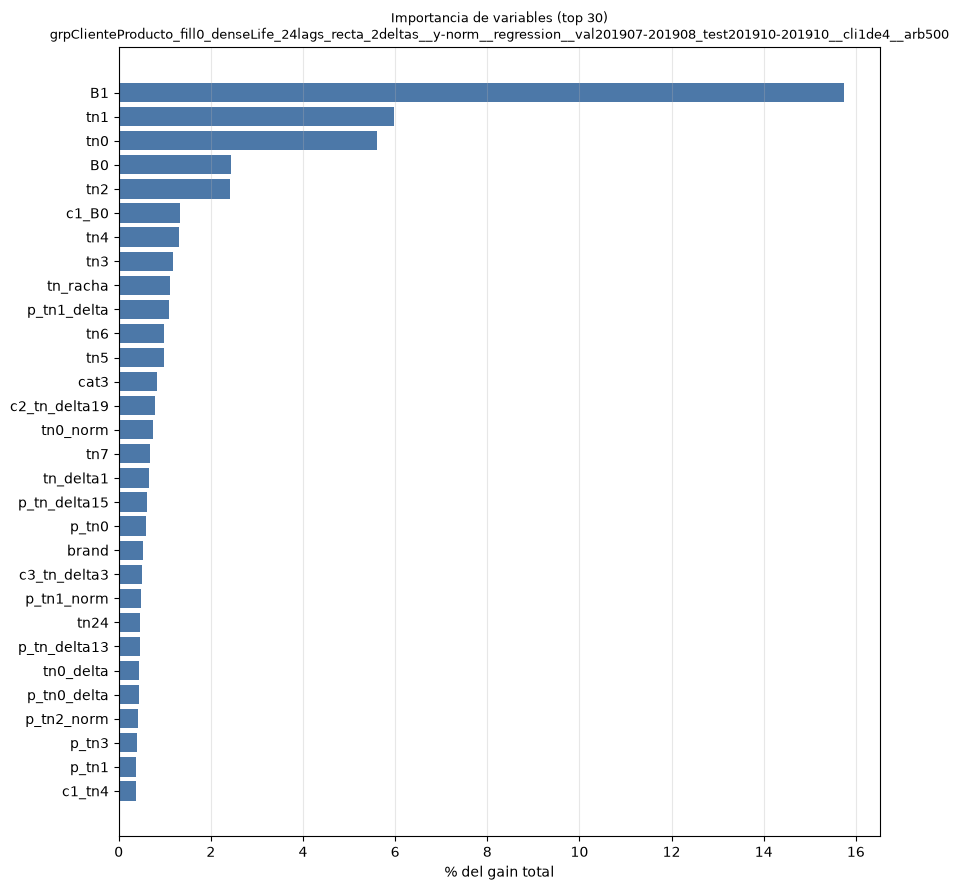

In [20]:
import matplotlib.pyplot as plt

top = imp.head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top['feature'], top['gain_pct'], color='#4C78A8')
ax.set_xlabel('% del gain total')
ax.set_title(f'Importancia de variables (top 30)\n{EXPERIMENTO}', fontsize=9)
ax.grid(axis='x', alpha=.3)
fig.tight_layout()
fig.savefig(DIR_OUT / 'importancia_top30.png', dpi=120)
plt.show()

In [ ]:
if PARAM.get('modo') == 'cluster':
    print('Modo cluster: se saltea el study global (seccion 6). Sigue en 6.bis.')
else:
    # ── Trials + graficos de Optuna ──────────────────────────────────────────
    df_trials = study.trials_dataframe()
    df_trials.to_csv(DIR_OUT / 'trials.csv', index=False)

    print("Top 10 trials:")
    print(df_trials[df_trials['state'] == 'COMPLETE']
          .sort_values('value')[['number', 'value']].head(10).to_string(index=False))

    try:
        import optuna.visualization as vis
        for nombre, fig_ in [
            ('historia',           vis.plot_optimization_history(study)),
            ('importancia_hiper',  vis.plot_param_importances(study)),
            ('slice',              vis.plot_slice(study)),
        ]:
            fig_.write_html(str(DIR_OUT / f'optuna_{nombre}.html'))
            fig_.show()
    except Exception as e:
        print(f"Graficos de Optuna no disponibles: {e}")

In [ ]:
if PARAM.get('modo') == 'cluster':
    print('Modo cluster: se saltea el study global (seccion 6). Sigue en 6.bis.')
else:
    # ── resultado.json: todo lo necesario para reproducir y para 04_entrenamiento_final ──
    resultado = {
        'experimento':        EXPERIMENTO,
        'dataset_fe':         PARAM['dataset_fe'],
        'config_dataset':     CFG,
        'target':             TARGET,
        'target_kind':        TARGET_KIND,
        'metodo_normalizacion': METODO,
        'horizonte':          H,
        'meses_train':        MESES_TRAIN,
        'meses_val':          MESES_VAL,
        'meses_test':         MESES_TEST,
        'meses_inferencia':   sorted(periodos_infer),
        'reentrenar_con_val_para_test': PARAM['reentrenar_con_val_para_test'],
        'metrica':            'wape_toneladas' + ('_por_producto' if PARAM['wape_por_producto'] else '_por_fila'),
        'wape_mejor_trial':   study.best_value,
        'wape_val':           wape_val,
        'wape_val_por_mes':   wape_val_mes,
        'wape_test':          wape_test,
        'wape_test_por_mes':  wape_test_mes,
        'wape_naive_val':     naive_val,
        'wape_naive_test':    naive_test,
        'n_trials_total':     len(study.trials),
        'objective_lgbm':     PARAM['objective_lgbm'],
        'regularizacion':     PARAM['regularizacion'],
        'techo_arboles':      int(PARAM.get('techo_arboles', 2000)),
        'decay_recencia':     PARAM['decay_recencia'],
        # Muestreo: 04 lo lee para saber con que datos se eligieron los hiperparametros.
        # Los meses de val/test NUNCA se muestrean, asi que wape_val y wape_test estan
        # medidos sobre datos completos y son comparables entre experimentos.
        'muestreo_clientes':  PARAM.get('muestreo_clientes'),
        'top_clientes':       PARAM.get('top_clientes'),
        'sampling_frac':      PARAM.get('sampling_frac'),
        'n_filas_cargadas':   int(len(df_pd)),
        'n_filas_train':      int(df_pd['periodo'].isin(MESES_TRAIN).sum()),
        'n_features':         len(FEATURES),
        'features':           FEATURES,
        'cat_features':       CAT_FEATURES,
        'features_excluir':   PARAM['features_excluir'],
        'features_sin_uso':   sin_uso,
        'hiperparametros':    study.best_params,
        'semilla':            PARAM['semilla'],
        'leakage':            leak['resumen'],
    }

    with open(DIR_OUT / 'resultado.json', 'w', encoding='utf-8') as f:
        json.dump(resultado, f, indent=2, ensure_ascii=False, default=str)

    # Backup del study al bucket (el .db local se pierde si se destruye la VM)
    shutil.copy(DB_LOCAL, DB_BUCKET)

    print(f"Guardado en {DIR_OUT}:")
    for p in sorted(DIR_OUT.iterdir()):
        print(f"  - {p.name}")
    print(f"\nBackup del study: {DB_BUCKET}")

## 8 — Leaderboard: comparar experimentos entre sí

`{BUCKET}/exp/leaderboard.csv` acumula una fila por experimento (upsert por nombre), leyendo
los `resultado.json` de todas las carpetas. Es la vista para decidir qué combinación de
palancas conviene.

In [23]:
filas = []
for d in sorted(RUTA_EXP.iterdir()):
    f_res = d / 'resultado.json'
    if not (d.is_dir() and f_res.exists()):
        continue
    r = json.load(open(f_res, encoding='utf-8'))
    _nt = r.get('wape_naive_test')
    filas.append({
        'experimento':   r['experimento'],
        'wape_test':     r.get('wape_test'),          # <- el numero honesto, ordena por este
        'wape_val':      r.get('wape_val'),
        'brecha_test_val': (round(r['wape_test'] - r['wape_val'], 5)
                            if r.get('wape_test') is not None and r.get('wape_val') is not None
                            else None),
        'wape_naive_test': _nt,
        'mejora_vs_naive_%': (round(100 * (_nt - r['wape_test']) / _nt, 2)
                              if _nt and r.get('wape_test') is not None else None),
        'meses_train':   f"{r['meses_train'][0]}-{r['meses_train'][-1]}" if r.get('meses_train') else None,
        'meses_val':     str(r.get('meses_val')),
        'meses_test':    str(r.get('meses_test')),
        'agrupamiento':  r['config_dataset']['agrupamiento'],
        'completado':    r['config_dataset']['completado'],
        'formato':       r['config_dataset']['formato'],
        'tgt_filter':    bool(r['config_dataset']['productos']),
        'max_lags':      r['config_dataset']['max_lags'],
        'norm':          r['config_dataset']['metodo'],
        'target':        r['target_kind'],
        'objective':     r['objective_lgbm'],
        'regularizacion': r['regularizacion'],
        # Con cuantos datos se busco: dos experimentos con muestreos distintos NO son
        # comparables en tiempo, aunque wape_val/test si lo sean (val y test nunca se
        # muestrean). Sin estas columnas el leaderboard esconde por que uno tardo 10x.
        'cli_muestreo':  r.get('muestreo_clientes'),
        'techo_arboles': r.get('techo_arboles'),
        'filas_train':   r.get('n_filas_train'),
        'n_features':    r['n_features'],
        'n_trials':      r['n_trials_total'],
        'leakage':       r['leakage'],
    })

leaderboard = pd.DataFrame(filas).sort_values('wape_test').reset_index(drop=True)
leaderboard.to_csv(RUTA_EXP / 'leaderboard.csv', index=False)

print(f"{len(leaderboard)} experimento(s) en {RUTA_EXP/'leaderboard.csv'}\n")
leaderboard

1 experimento(s) en /home/ds/buckets/b1/exp/leaderboard.csv



,experimento,wape_test,wape_val,brecha_test_val,wape_naive_test,mejora_vs_naive_%,meses_train,meses_val,meses_test,agrupamiento,...,norm,target,objective,regularizacion,cli_muestreo,techo_arboles,filas_train,n_features,n_trials,leakage
0,grpClienteProducto_fill0_denseLife_24lags_rect...,0.478758,0.19005,0.28871,0.493989,3.08,201701-201905,"[201907, 201908]",[201910],grpClienteProducto,...,recta,norm,regression,normal,4,500,2123584,609,50,"0 error(es), 0 warning(s)"
